# Ejercicio de programación Regresión Lineal Multiple

In [1]:

import os
import pandas as pd
import numpy as np

from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

%matplotlib inline

from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [2]:
ruta_dataset = '/content/gdrive/MyDrive/SIS420/datasets/kc_house_data_NaN.csv'
df = pd.read_csv(ruta_dataset)


print(f"Número de filas (m): {df.shape[0]}")
print(f"Número de columnas (n): {df.shape[1]}")

print("\nPrimeras 5 filas del dataset:")
print(df.head())




Número de filas (m): 21613
Número de columnas (n): 22

Primeras 5 filas del dataset:
   Unnamed: 0          id             date     price  bedrooms  bathrooms  \
0           0  7129300520  20141013T000000  221900.0       3.0       1.00   
1           1  6414100192  20141209T000000  538000.0       3.0       2.25   
2           2  5631500400  20150225T000000  180000.0       2.0       1.00   
3           3  2487200875  20141209T000000  604000.0       4.0       3.00   
4           4  1954400510  20150218T000000  510000.0       3.0       2.00   

   sqft_living  sqft_lot  floors  waterfront  ...  grade  sqft_above  \
0         1180      5650     1.0           0  ...      7        1180   
1         2570      7242     2.0           0  ...      7        2170   
2          770     10000     1.0           0  ...      6         770   
3         1960      5000     1.0           0  ...      7        1050   
4         1680      8080     1.0           0  ...      8        1680   

   sqft_basement  y

In [3]:
print("\nValores nulos por columna")
print(df.isnull().sum())

df_clean = df.dropna()


feature_columns = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement',
                   'bathrooms', 'bedrooms', 'floors', 'yr_built']

X = df_clean[feature_columns].values
y = df_clean['price'].values

m = y.shape[0]
n = X.shape[1]

print(f"Número de ejemplos de entrenamiento (m): {m}")
print(f"Número de características (n): {n}")



Valores nulos por columna
Unnamed: 0        0
id                0
date              0
price             0
bedrooms         13
bathrooms        10
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64
Número de ejemplos de entrenamiento (m): 21597
Número de características (n): 8


In [4]:

def featureNormalize(X):

    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print(f"Media calculada: {mu}")
print(f"Desviación estándar calculada: {sigma}")
print(f"Primeras 5 filas normalizadas:\n{X_norm[:5]}")

Media calculada: [2.08032185e+03 1.50994088e+04 1.78859684e+03 2.91725008e+02
 2.11582627e+00 3.37319998e+00 1.49409640e+00 1.97099968e+03]
Desviación estándar calculada: [9.18084869e+02 4.14116781e+04 8.27740597e+02 4.42657552e+02
 7.68966493e-01 9.26277449e-01 5.39670296e-01 2.93745540e+01]
Primeras 5 filas normalizadas:
[[-0.98065209 -0.22818222 -0.73525069 -0.65903091 -1.45107268 -0.40290302
  -0.91555234 -0.54467809]
 [ 0.53336915 -0.18973896  0.46077619  0.24460216  0.17448579 -0.40290302
   0.93743087 -0.68085037]
 [-1.4272339  -0.12313939 -1.23057495 -0.65903091 -1.45107268 -1.48249316
  -0.91555234 -1.29362563]
 [-0.13105744 -0.24387828 -0.89230472  1.39673431  1.14982088  0.67668712
  -0.91555234 -0.20424739]
 [-0.43604013 -0.16950312 -0.13119671 -0.65903091 -0.1506259  -0.40290302
  -0.91555234  0.54470015]]


In [5]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

        if i % 500 == 0:
            print(f"Iteración {i}: Costo = {J_history[-1]}")

    return theta, J_history


X_with_intercept = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print(f"Dimensiones de X con intersección: {X_with_intercept.shape}")

Dimensiones de X con intersección: (21597, 9)


Iteración 0: Costo = 169665511971.818
Iteración 500: Costo = 29893496165.393776
Iteración 1000: Costo = 29893496165.393776
Iteración 1500: Costo = 29893496165.393776
Iteración 0: Costo = 109936399770.69
Iteración 500: Costo = 29893496165.393784
Iteración 1000: Costo = 29893496165.393784
Iteración 1500: Costo = 29893496165.393784
Iteración 0: Costo = 86927279187.29308
Iteración 500: Costo = 29893496165.393776
Iteración 1000: Costo = 29893496165.393776
Iteración 1500: Costo = 29893496165.393776


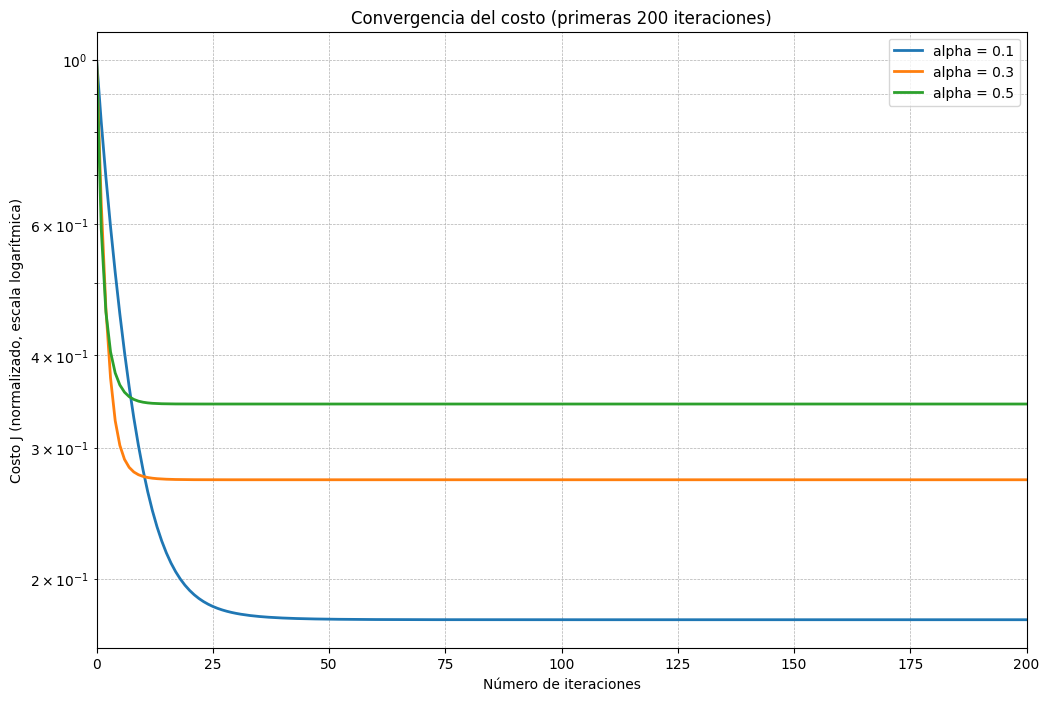

In [6]:

alphas = [0.1, 0.3, 0.5]
num_iters = 2000

plt.figure(figsize=(12, 8))

for alpha in alphas:
    theta = np.zeros(X_with_intercept.shape[1])
    theta, J_history = gradientDescentMulti(X_with_intercept, y, theta, alpha, num_iters)
    J_history_norm = np.array(J_history) / J_history[0]
    plt.semilogy(np.arange(len(J_history_norm)), J_history_norm,
                 label=f'alpha = {alpha}', lw=2)

plt.xlim(0, 200)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J (normalizado, escala logarítmica)')
plt.title('Convergencia del costo (primeras 200 iteraciones)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [7]:

best_alpha = 0.5
num_iters = 5000

print(f"\nEntrenando con alpha = {best_alpha} y {num_iters} iteraciones...")

theta = np.zeros(X_with_intercept.shape[1])
theta, J_history = gradientDescentMulti(X_with_intercept, y, theta, best_alpha, num_iters)

print(f"\nTheta final: {theta}")
print(f"Costo final: {J_history[-1]}")


Entrenando con alpha = 0.5 y 5000 iteraciones...
Iteración 0: Costo = 86927279187.29308
Iteración 500: Costo = 29893496165.393776
Iteración 1000: Costo = 29893496165.393776
Iteración 1500: Costo = 29893496165.393776
Iteración 2000: Costo = 29893496165.393776
Iteración 2500: Costo = 29893496165.393776
Iteración 3000: Costo = 29893496165.393776
Iteración 3500: Costo = 29893496165.393776
Iteración 4000: Costo = 29893496165.393776
Iteración 4500: Costo = 29893496165.393776

Theta final: [540202.91975737 142476.5807908  -12965.66677964 125390.6371004
  61028.37762444  53320.86980452 -63779.09908759  26538.47990449
 -99970.45678722]
Costo final: 29893496165.393776


In [8]:

def normalEqn(X, y):

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

X_with_intercept_raw = np.concatenate([np.ones((m, 1)), X], axis=1)
theta_normal = normalEqn(X_with_intercept_raw, y)

print(f"Theta calculado con ecuación normal: {theta_normal}")
print(f"Costo con ecuación normal: {computeCostMulti(X_with_intercept_raw, y, theta_normal)}")

Theta calculado con ecuación normal: [ 5.70443638e+06 -6.79264961e+03  1.68041492e-01  7.07408431e+03
  7.09794983e+03  6.93409534e+04 -6.88552864e+04  4.91753578e+04
 -3.40330126e+03]
Costo con ecuación normal: 491799620758.43536


In [9]:

def predict_price(theta, features, mu, sigma):

    features_norm = (features - mu) / sigma

    features_with_intercept = np.concatenate([[1], features_norm])
    return np.dot(features_with_intercept, theta)

def make_prediction(theta, mu, sigma, sqft_living, sqft_lot, sqft_above,
                   sqft_basement, bathrooms, bedrooms, floors, yr_built):
    features = np.array([sqft_living, sqft_lot, sqft_above, sqft_basement,
                        bathrooms, bedrooms, floors, yr_built])
    return predict_price(theta, features, mu, sigma)

predicted_price = make_prediction(theta, mu, sigma,
                                 sqft_living=2000,
                                 sqft_lot=5000,
                                 sqft_above=1800,
                                 sqft_basement=200,
                                 bathrooms=2.5,
                                 bedrooms=3,
                                 floors=2,
                                 yr_built=2005)

print(f"\n PREDICCIÓN DE PRECIO")
print(f"Casa de 2000 sqft, 3 dormitorios, 2.5 baños, construida en 2005")
print(f"Precio predicho: ${predicted_price:,.2f}")


 PREDICCIÓN DE PRECIO
Casa de 2000 sqft, 3 dormitorios, 2.5 baños, construida en 2005
Precio predicho: $481,481.77
